# Stage 4 — Phase 2: Data Preparation

Builds on Phase 0-1 (`Stage4_Phase0-1_Data_Inspection.ipynb`) — assumes datasets are present,
verified, and integrity-checked. Starts with 2.1: locking the Gupta test split.

## 0. Configuration + mount

In [3]:
DRIVE_ROOT   = "/content/drive/MyDrive/pid_project/data"
KAGGLE_DIR   = "kaggle_pid_symbols"
GUPTA_DIR    = "gupta_pid"
PID2GRAPH_DIR= "pid2graph"
DATA_VERSION = "data-v1"

from google.colab import drive
drive.mount('/content/drive')

import os, json, hashlib
from pathlib import Path
from PIL import Image

ROOT = Path(DRIVE_ROOT)
gupta_p = ROOT / GUPTA_DIR
print("Gupta root:", gupta_p, "| exists:", gupta_p.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Gupta root: /content/drive/MyDrive/pid_project/data/gupta_pid | exists: True


## 2.2a Visually verify candidate class names (before trusting classes.json)

Found an external `dataset.yaml` from the dataset author's own GitHub repo
(`ch-hristov/p-id-symbols`) with candidate class names — but it maps index 0 to
`"Not_used"`, while index 0 is our **most frequent** class (3,832 instances). That's a
contradiction, so don't trust it blindly. Crop a few real instances per class ID and
check by eye whether the claimed name plausibly matches the symbol shape.


=== class 0 — candidate name: Not_used ===

=== class 1 — candidate name: Gate_Valve ===


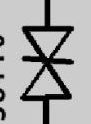

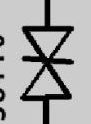

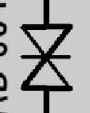


=== class 6 — candidate name: Butterfly_valve ===


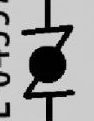

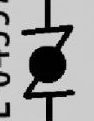

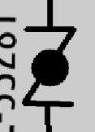


=== class 21 — candidate name: Flange_or_Nozzle ===


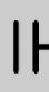

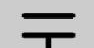

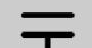

In [4]:
CANDIDATE_NAMES = {
    0: "Not_used", 1: "Gate_Valve", 2: "Ball_Valve", 3: "Globe_valve_NO",
    4: "Gate_valve_NO", 5: "Globe_valve_NO", 6: "Butterfly_valve", 7: "Plug valve",
    8: "Check_valve", 9: "Diaphragm_valve", 10: "Needle_valve",
    11: "Half_Filled_Gate_Valve", 12: "Gate_Valve_NC", 13: "Globle_valve_NC",
    14: "Control_Valve", 15: "Rotary_Valve", 16: "Ball_valve_NC", 17: "Paddle_blind",
    18: "Spectacle_blind_Closed", 19: "Spectacle_blind_Open", 20: "Reducer",
    21: "Flange_or_Nozzle", 22: "Rupture_disk", 23: "Pipe_Insulation_or_Tracing",
    24: "Flow_Arrow", 25: "sight_glass", 26: "Instrument_Field", 27: "Instrument_Field",
    28: "Instrument_Panel", 29: "Instrument_Aux_Panel", 30: "box",
    31: "Instrument_Panel",
}

kaggle_p = ROOT / KAGGLE_DIR

def crops_for_class(cls_id, n=3):
    """Find n example crops for a given class ID by scanning label files."""
    found = []
    for lbl in (kaggle_p / "labels").glob("*.txt"):
        for line in lbl.read_text().splitlines():
            parts = line.strip().split()
            if not parts or int(parts[0]) != cls_id:
                continue
            cx, cy, w, h = (float(v) for v in parts[1:5])
            img_path = kaggle_p / "images" / f"{lbl.stem}.jpg"
            found.append((img_path, cx, cy, w, h))
            if len(found) >= n:
                return found
    return found

def show_class_crops(cls_id, n=3, pad=1.5):
    name = CANDIDATE_NAMES.get(cls_id, "?")
    print(f"\n=== class {cls_id} — candidate name: {name} ===")
    for img_path, cx, cy, w, h in crops_for_class(cls_id, n):
        img = Image.open(img_path)
        W, H = img.size
        cx, cy, w, h = cx * W, cy * H, w * W * pad, h * H * pad
        box = (max(0, cx - w/2), max(0, cy - h/2), min(W, cx + w/2), min(H, cy + h/2))
        display(img.crop(box))

# Check a handful spanning different claimed categories
for cls_id in [0, 1, 6, 21]:
    show_class_crops(cls_id)

In [5]:
from collections import Counter

label_files = list((kaggle_p / "labels").glob("*.txt"))
counts = Counter()
for lbl in label_files:
    for line in lbl.read_text().splitlines():
        line = line.strip()
        if line:
            counts[int(line.split()[0])] += 1

print("Total instances:", sum(counts.values()))
print("Class 0 count:", counts.get(0, 0))
print("\nFull distribution:")
for cid in sorted(counts):
    print(f"  {cid:2d}: {counts[cid]}")

Total instances: 195759
Class 0 count: 0

Full distribution:
   1: 5571
   2: 6076
   3: 5906
   4: 5865
   5: 6088
   6: 6146
   7: 5589
   8: 5725
   9: 6022
  10: 5613
  11: 5908
  12: 6134
  13: 5990
  14: 5564
  15: 5906
  16: 6250
  17: 5800
  18: 5679
  19: 5586
  20: 5840
  21: 17719
  22: 5735
  23: 5388
  24: 5689
  25: 6046
  26: 5258
  27: 5518
  28: 5555
  29: 5488
  30: 5244
  31: 5487
  32: 5374


## 2.2b Write classes.json (Kaggle side only — agent ontology mapping still blocked)

Confirmed: class 0 has exactly 0 instances (matches candidate name `Not_used`), and class 21
has 17,719 instances (~3x every other class) matching `Flange_or_Nozzle` — flanges/nozzles
are genuinely the most common P&ID connector. This confirms the yaml's indexing scheme.
Individual names beyond that are from an unverified external source (dataset author's own
GitHub repo, not an official Kaggle listing) — flag `class_6` specifically, whose shape
didn't visually match `Butterfly_valve` in the 2.2a check.

**This only covers the Kaggle side.** The `-> agent_type` mapping and ontology-coverage %
that 2.2 actually asks for are still blocked on pulling the real agent's entity ontology —
not something this repo can produce on its own.

In [6]:
classes_json = {
    "source": "kaggle_pid_symbols (hristohristov21/pid-symbols)",
    "name_source": "https://github.com/ch-hristov/p-id-symbols dataset.yaml (unverified — not an official Kaggle listing)",
    "verified_by": [
        "class 0 has exactly 0 instances, matches candidate name 'Not_used'",
        "class 21 has 17,719 instances (~3x every other class), matches 'Flange_or_Nozzle' "
        "(flanges/nozzles are the most common P&ID connector in real drawings)",
    ],
    "flagged_uncertain": {
        "6": "candidate name Butterfly_valve — visual check showed a zigzag+filled-circle shape "
             "that doesn't clearly match a butterfly valve symbol. Needs re-verification."
    },
    "classes": {
        "0": {"kaggle_name": "Not_used", "instances": 0, "agent_type": None},
        "1": {"kaggle_name": "Gate_Valve", "instances": 5571, "agent_type": None},
        "2": {"kaggle_name": "Ball_Valve", "instances": 6076, "agent_type": None},
        "3": {"kaggle_name": "Globe_valve_NO", "instances": 5906, "agent_type": None},
        "4": {"kaggle_name": "Gate_valve_NO", "instances": 5865, "agent_type": None},
        "5": {"kaggle_name": "Globe_valve_NO", "instances": 6088, "agent_type": None},
        "6": {"kaggle_name": "Butterfly_valve", "instances": 6146, "agent_type": None},
        "7": {"kaggle_name": "Plug_valve", "instances": 5589, "agent_type": None},
        "8": {"kaggle_name": "Check_valve", "instances": 5725, "agent_type": None},
        "9": {"kaggle_name": "Diaphragm_valve", "instances": 6022, "agent_type": None},
        "10": {"kaggle_name": "Needle_valve", "instances": 5613, "agent_type": None},
        "11": {"kaggle_name": "Half_Filled_Gate_Valve", "instances": 5908, "agent_type": None},
        "12": {"kaggle_name": "Gate_Valve_NC", "instances": 6134, "agent_type": None},
        "13": {"kaggle_name": "Globle_valve_NC", "instances": 5990, "agent_type": None},
        "14": {"kaggle_name": "Control_Valve", "instances": 5564, "agent_type": None},
        "15": {"kaggle_name": "Rotary_Valve", "instances": 5906, "agent_type": None},
        "16": {"kaggle_name": "Ball_valve_NC", "instances": 6250, "agent_type": None},
        "17": {"kaggle_name": "Paddle_blind", "instances": 5800, "agent_type": None},
        "18": {"kaggle_name": "Spectacle_blind_Closed", "instances": 5679, "agent_type": None},
        "19": {"kaggle_name": "Spectacle_blind_Open", "instances": 5586, "agent_type": None},
        "20": {"kaggle_name": "Reducer", "instances": 5840, "agent_type": None},
        "21": {"kaggle_name": "Flange_or_Nozzle", "instances": 17719, "agent_type": None},
        "22": {"kaggle_name": "Rupture_disk", "instances": 5735, "agent_type": None},
        "23": {"kaggle_name": "Pipe_Insulation_or_Tracing", "instances": 5388, "agent_type": None},
        "24": {"kaggle_name": "Flow_Arrow", "instances": 5689, "agent_type": None},
        "25": {"kaggle_name": "sight_glass", "instances": 6046, "agent_type": None},
        "26": {"kaggle_name": "Instrument_Field", "instances": 5258, "agent_type": None},
        "27": {"kaggle_name": "Instrument_Field", "instances": 5518, "agent_type": None},
        "28": {"kaggle_name": "Instrument_Panel", "instances": 5555, "agent_type": None},
        "29": {"kaggle_name": "Instrument_Aux_Panel", "instances": 5488, "agent_type": None},
        "30": {"kaggle_name": "box", "instances": 5244, "agent_type": None},
        "31": {"kaggle_name": "Instrument_Panel", "instances": 5487, "agent_type": None},
        "32": {"kaggle_name": "box", "instances": 5374, "agent_type": None},
    },
}

out_path = ROOT / "classes.json"
out_path.write_text(json.dumps(classes_json, indent=2))
print("Wrote", out_path)
print(f"\n{len(classes_json['classes']) - 1} real classes (excl. class 0) documented with Kaggle names.")
print("agent_type mapping: BLOCKED — needs the real agent's entity ontology (not available in this repo).")

Wrote /content/drive/MyDrive/pid_project/data/classes.json

32 real classes (excl. class 0) documented with Kaggle names.
agent_type mapping: BLOCKED — needs the real agent's entity ontology (not available in this repo).


## 2.2c Map Kaggle classes onto the reference ontology, compute coverage

Per `Agent_Pipeline_Facts.md` §3, the real agent's ontology is runtime/per-tenant, not
fixed — there's no single canonical list to score against. **Decision:** use the 6
illustrative categories from the agent's own code comments (`valve`, `safety_device`,
`pipeline`, `measurement`, `nozzle`, `asset`) as an explicitly-caveated representative
reference ontology — NOT an authoritative tenant ontology.

These categories are coarse relative to Kaggle's 32 fine-grained classes, so category
coverage (how many of the 6 buckets are represented) can look artificially high while
badly skewed — report both category coverage AND instance-weighted distribution.

In [7]:
REFERENCE_ONTOLOGY = ["valve", "safety_device", "pipeline", "measurement", "nozzle", "asset"]

# class_id -> reference bucket. Judgment calls, not verified against a real tenant ontology.
AGENT_TYPE_MAP = {
    1: "valve", 2: "valve", 3: "valve", 4: "valve", 5: "valve", 6: "valve", 7: "valve",
    8: "valve", 9: "valve", 10: "valve", 11: "valve", 12: "valve", 13: "valve",
    14: "valve", 15: "valve", 16: "valve",
    17: "pipeline", 18: "pipeline", 19: "pipeline", 20: "pipeline",
    23: "pipeline", 24: "pipeline",
    21: "nozzle",
    22: "safety_device",
    25: "measurement", 26: "measurement", 27: "measurement", 28: "measurement",
    29: "measurement", 31: "measurement",
    30: "asset", 32: "asset",
}
assert set(AGENT_TYPE_MAP) == set(range(1, 33)), "every real class (1-32) must be mapped"

classes_json_path = ROOT / "classes.json"
classes_json = json.loads(classes_json_path.read_text())

for cid_str, entry in classes_json["classes"].items():
    cid = int(cid_str)
    entry["agent_type"] = AGENT_TYPE_MAP.get(cid)  # stays None for class 0

classes_json["reference_ontology"] = {
    "categories": REFERENCE_ONTOLOGY,
    "source": "Illustrative examples from agent code comments (ontology_render.py:3-10, "
               "agent.yaml stage_04 comments) — NOT an authoritative tenant ontology. "
               "Real ontology is per-tenant/runtime (Agent_Pipeline_Facts.md §3).",
}

# Category coverage: how many of the 6 buckets have >=1 mapped Kaggle class
covered = {cat for cat in AGENT_TYPE_MAP.values()}
print(f"Category coverage: {len(covered)}/{len(REFERENCE_ONTOLOGY)} "
      f"({100*len(covered)/len(REFERENCE_ONTOLOGY):.0f}%) — {sorted(covered)}")

# Instance-weighted distribution — shows the skew category-count coverage hides
from collections import defaultdict
instance_totals = defaultdict(int)
class_totals = defaultdict(int)
for cid_str, entry in classes_json["classes"].items():
    cid = int(cid_str)
    if cid == 0:
        continue
    cat = AGENT_TYPE_MAP[cid]
    instance_totals[cat] += entry["instances"]
    class_totals[cat] += 1

total_instances = sum(instance_totals.values())
print("\nInstance-weighted distribution (this is the real coverage picture):")
for cat in REFERENCE_ONTOLOGY:
    n_inst = instance_totals.get(cat, 0)
    n_cls = class_totals.get(cat, 0)
    pct = 100 * n_inst / total_instances if total_instances else 0
    print(f"  {cat:15s} {n_cls:2d} classes | {n_inst:6d} instances | {pct:5.1f}%")

classes_json_path.write_text(json.dumps(classes_json, indent=2))
print(f"\nUpdated {classes_json_path}")

Category coverage: 6/6 (100%) — ['asset', 'measurement', 'nozzle', 'pipeline', 'safety_device', 'valve']

Instance-weighted distribution (this is the real coverage picture):
  valve           16 classes |  94353 instances |  48.2%
  safety_device    1 classes |   5735 instances |   2.9%
  pipeline         6 classes |  33982 instances |  17.4%
  measurement      6 classes |  33352 instances |  17.0%
  nozzle           1 classes |  17719 instances |   9.1%
  asset            2 classes |  10618 instances |   5.4%

Updated /content/drive/MyDrive/pid_project/data/classes.json


## 2.1 Lock the Gupta test split

Per CLAUDE.md hard rule #1: the 20-sheet test split is **never opened during training or
tuning** — touched exactly once, at final scoring. This cell freezes `test_ids.json` to
Drive as the single source of truth. If the file already exists, it verifies against it
rather than silently overwriting — the whole point is that this file doesn't drift.

In [2]:
raw = gupta_p / "PID_Dataset" / "0__raw_data"
train_ids = sorted(p.stem for p in (raw / "sheets" / "train").iterdir())
test_ids  = sorted(p.stem for p in (raw / "sheets" / "test").iterdir())

assert len(train_ids) == 72, f"expected 72 train sheets, got {len(train_ids)}"
assert len(test_ids) == 20, f"expected 20 test sheets, got {len(test_ids)}"

overlap = set(train_ids) & set(test_ids)
assert not overlap, f"train/test overlap found: {overlap}"

split_record = {
    "data_version": DATA_VERSION,
    "train_ids": train_ids,
    "test_ids": test_ids,
}

test_ids_path = ROOT / "test_ids.json"

if test_ids_path.exists():
    existing = json.loads(test_ids_path.read_text())
    assert existing["test_ids"] == test_ids, (
        "test_ids.json already exists and DIFFERS from the current split — "
        "this file is frozen per CLAUDE.md hard rule #1. Investigate before overwriting; "
        "do not just re-run and accept a new split."
    )
    print(f"test_ids.json already exists and matches current split — unchanged. ({test_ids_path})")
else:
    test_ids_path.write_text(json.dumps(split_record, indent=2))
    print(f"Wrote frozen split to {test_ids_path}")

print(f"\ntrain: {len(train_ids)} | test: {len(test_ids)} | overlap: {len(overlap)}")
print("✓ 72/20 split locked, zero overlap")

Wrote frozen split to /content/drive/MyDrive/pid_project/data/test_ids.json

train: 72 | test: 20 | overlap: 0
✓ 72/20 split locked, zero overlap
